# Creative Fatigue — Time-Varying Cox with Daily Data

The previous two notebooks used only **static** features measured at launch. But the real driver of fatigue is not how the creative *looks* — it is how much the audience has already been **exposed** to it.

This notebook uses the granular daily table (`creative_daily_country_os_stats.csv`) to build a **time-varying Cox model** where:
- `impressions_last_7d` — accumulated exposure in the last week — is a time-varying covariate.
- Daily CTR and CVR trends are computed and used as early-warning signals.
- The model is refit in `(start, stop, event)` format (counting-process notation), which is the standard for time-varying covariates in survival analysis.

**Key question answered here:**
> *At what cumulative exposure level does a creative start dying? And does this threshold differ by format and vertical?*

Libraries: `lifelines`, `pandas`, `numpy`, `matplotlib`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split

from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
np.random.seed(42)

DATA = '../data'


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

## 1. Load the daily granular table

192,315 rows: one per `date × creative × country × OS`. We aggregate to `creative × day` level (sum spend/impressions/clicks/conversions across countries and OSes) so each creative has a single daily record.

In [2]:
daily_raw = pd.read_csv(f'{DATA}/creative_daily_country_os_stats.csv', parse_dates=['date'])
crs_summary = pd.read_csv(f'{DATA}/creative_summary.csv')

print(f'Raw daily rows : {len(daily_raw):,}')
print(f'Creatives      : {daily_raw["creative_id"].nunique():,}')
print(f'Date range     : {daily_raw["date"].min().date()} → {daily_raw["date"].max().date()}')
print()
print(daily_raw.dtypes)

Raw daily rows : 192,315
Creatives      : 1,080
Date range     : 2026-01-01 → 2026-03-16

date                    datetime64[ns]
campaign_id                      int64
creative_id                      int64
country                         object
os                              object
days_since_launch                int64
impressions_last_7d              int64
spend_usd                      float64
impressions                      int64
viewable_impressions             int64
clicks                           int64
conversions                      int64
revenue_usd                    float64
video_completions                int64
dtype: object


In [3]:
# Aggregate across country × OS → creative × day
agg_cols = {
    'spend_usd':            'sum',
    'impressions':          'sum',
    'viewable_impressions': 'sum',
    'clicks':               'sum',
    'conversions':          'sum',
    'revenue_usd':          'sum',
    'video_completions':    'sum',
    'impressions_last_7d':  'max',   # same value for all country/OS in a given day
    'days_since_launch':    'max',
}

daily = (
    daily_raw
    .groupby(['creative_id', 'campaign_id', 'date'], as_index=False)
    .agg(agg_cols)
    .sort_values(['creative_id', 'days_since_launch'])
    .reset_index(drop=True)
)

# Derived daily metrics
daily['ctr']          = (daily['clicks'] / daily['impressions'].clip(lower=1))
daily['cvr']          = (daily['conversions'] / daily['clicks'].clip(lower=1))
daily['viewability']  = (daily['viewable_impressions'] / daily['impressions'].clip(lower=1))

print(f'After aggregation: {len(daily):,} creative-day rows')
print(daily.head(3).to_string())

After aggregation: 52,349 creative-day rows
   creative_id  campaign_id       date  spend_usd  impressions  viewable_impressions  clicks  conversions  revenue_usd  video_completions  impressions_last_7d  days_since_launch       ctr       cvr  viewability
0       500000        20000 2026-01-19    5917.42       940460                769746   10626         2156     11713.79                  0               851578                  0  0.011299  0.202899     0.818478
1       500000        20000 2026-01-20    2669.38       450862                376573    4302          905      4990.81                  0               622696                  1  0.009542  0.210367     0.835229
2       500000        20000 2026-01-21    2804.97       455904                381052    3924          721      4024.43                  0               447226                  2  0.008607  0.183741     0.835816


## 2. Merge fatigue labels from creative_summary

Each creative has a `creative_status` and, if fatigued, a `fatigue_day`. We merge these from the summary table so we know which day is the event day for each creative.

Important modelling detail: the event is attached to the interval **ending** at `fatigue_day`, so the model only uses information available *before* the event fires.

In [4]:
label_cols = ['creative_id', 'creative_status', 'fatigue_day', 'total_days_active',
              'vertical', 'format', 'dominant_color', 'emotional_tone',
              'text_density', 'clutter_score', 'novelty_score', 'motion_score',
              'has_gameplay', 'has_ugc_style', 'has_price', 'has_discount_badge']

daily = daily.merge(crs_summary[label_cols], on='creative_id', how='left')

# Boolean: is this creative fatigued?
daily['is_fatigued'] = (daily['creative_status'] == 'fatigued').astype(int)

# One row = state observed on day t, used for interval [t, t+1).
# The event is attached to the interval ending at fatigue_day so we avoid same-day leakage.
daily['start'] = daily['days_since_launch']
daily['stop']  = daily['days_since_launch'] + 1
daily['event_on_stop'] = (
    (daily['is_fatigued'] == 1) &
    (daily['stop'] == daily['fatigue_day'])
).astype(int)

daily['observed_duration'] = np.where(
    daily['is_fatigued'] == 1,
    daily['fatigue_day'],
    daily['total_days_active'],
)

print(f'Total events (fatigue days): {daily["event_on_stop"].sum()}')
print(f'Should match fatigued creatives: {crs_summary[crs_summary["creative_status"]=="fatigued"].shape[0]}')

Total events (fatigue days): 199
Should match fatigued creatives: 199


## 3. Compute time-varying covariates

We compute the following **per-creative-per-day** metrics that a time-varying model can use:

| Feature | Computation | Intuition |
|---|---|---|
| `log_impressions_last7d` | log(impressions_last_7d + 1) | Cumulative exposure — main fatigue driver |
| `ctr_vs_peak` | CTR today / max CTR so far | Decay ratio: 1.0 = still at peak, 0.5 = half |
| `cvr_vs_peak` | CVR today / max CVR so far | Conversion decay |
| `spend_velocity_7d` | sum(spend last 7d) / 7 | How aggressively the creative is being pushed |
| `ctr_7d_slope` | linear slope of CTR over last 7 days | Trend: negative = declining |

These are all quantities you would know *before* the event fires — no leakage.

In [5]:
daily = daily.sort_values(['creative_id', 'days_since_launch']).reset_index(drop=True)

# Log-transformed cumulative exposure
daily['log_impressions_last7d'] = np.log1p(daily['impressions_last_7d'])

# CTR and CVR relative to each creative's rolling peak (no future leakage)
daily['ctr_peak_so_far'] = daily.groupby('creative_id')['ctr'].transform(
    lambda x: x.expanding().max()
)
daily['cvr_peak_so_far'] = daily.groupby('creative_id')['cvr'].transform(
    lambda x: x.expanding().max()
)
daily['ctr_vs_peak'] = (daily['ctr'] / daily['ctr_peak_so_far'].clip(lower=1e-9)).clip(0, 1)
daily['cvr_vs_peak'] = (daily['cvr'] / daily['cvr_peak_so_far'].clip(lower=1e-9)).clip(0, 1)

# 7-day rolling spend velocity
daily['spend_velocity_7d'] = (
    daily.groupby('creative_id')['spend_usd']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# 7-day CTR slope (linear trend)
def rolling_slope(series, window=7):
    slopes = [np.nan] * len(series)
    arr = series.values
    for i in range(len(arr)):
        start = max(0, i - window + 1)
        chunk = arr[start:i+1]
        if len(chunk) >= 2:
            x = np.arange(len(chunk), dtype=float)
            slopes[i] = float(np.polyfit(x, chunk, 1)[0])
        else:
            slopes[i] = 0.0
    return slopes

daily['ctr_7d_slope'] = daily.groupby('creative_id')['ctr'].transform(rolling_slope)

# Fill any remaining NaNs
tv_cols = ['log_impressions_last7d', 'ctr_vs_peak', 'cvr_vs_peak', 'spend_velocity_7d', 'ctr_7d_slope']
daily[tv_cols] = daily[tv_cols].fillna(method='ffill').fillna(0)

print('Time-varying features computed.')
print(daily[tv_cols].describe().round(3).to_string())

Time-varying features computed.
       log_impressions_last7d  ctr_vs_peak  cvr_vs_peak  spend_velocity_7d  ctr_7d_slope
count               52349.000    52349.000    52349.000          52349.000     52349.000
mean                   12.355        0.411        0.762            653.116        -0.000
std                     0.695        0.268        0.173            486.968         0.000
min                     7.125        0.076        0.000            167.000        -0.005
25%                    11.910        0.197        0.649            416.460        -0.000
50%                    12.334        0.306        0.780            535.961        -0.000
75%                    12.781        0.577        0.897            714.110        -0.000
max                    15.628        1.000        1.000          10471.690         0.003


## 4. Reshape to counting-process (start, stop, event) format

For a time-varying Cox model in `lifelines`, each row represents the interval `[start, stop)` during which the covariate values are constant. In our case, each row is one day, and the event is attached to the interval endpoint so the model only uses information available before fatigue is marked:

```
creative_id | start | stop | event_on_stop | log_impressions_last7d | ctr_vs_peak | ...
500001      |   0   |   1  |  0    |         8.4            |    1.00     |
500001      |   1   |   2  |  0    |        10.1            |    0.95     |
...         |  ...  |  ... |  ...  |         ...            |    ...      |
500001      |  11   |  12  |  1    |        15.8            |    0.41     |  ← event fires
```

This avoids same-day leakage and makes the notebook suitable for real-time monitoring as well as retrospective explanation.

In [6]:
# Static creative features to include as time-fixed covariates
static_cols = ['text_density', 'clutter_score', 'novelty_score', 'motion_score',
               'has_gameplay', 'has_ugc_style', 'has_price', 'has_discount_badge']

# Keep only intervals observed before censoring or fatigue
daily_valid = daily[daily['stop'] <= daily['observed_duration']].copy()

# Categorical dummies for format and vertical
daily_model = daily_valid.copy()
daily_model = pd.get_dummies(daily_model, columns=['format', 'vertical'], drop_first=True, dtype=float)

format_dummies   = [c for c in daily_model.columns if c.startswith('format_')]
vertical_dummies = [c for c in daily_model.columns if c.startswith('vertical_')]

model_cols = (
    ['creative_id', 'start', 'stop', 'event_on_stop'] +
    tv_cols +
    static_cols +
    format_dummies +
    vertical_dummies
)

tv_df = daily_model[model_cols].copy().fillna(0)

# Hold out complete creatives so predictive evaluation is honest.
creative_split = daily[['creative_id', 'is_fatigued']].drop_duplicates('creative_id')
train_ids, test_ids = train_test_split(
    creative_split['creative_id'],
    test_size=0.2,
    stratify=creative_split['is_fatigued'],
    random_state=42,
)

tv_df_train = tv_df[tv_df['creative_id'].isin(train_ids)].copy()
tv_df_test  = tv_df[tv_df['creative_id'].isin(test_ids)].copy()
score_feature_cols = [c for c in tv_df.columns if c not in ['creative_id', 'start', 'stop', 'event_on_stop']]

print(f'Time-varying model frame: {tv_df.shape}')
print(f'Train creative-days: {tv_df_train.shape[0]:,}')
print(f'Test creative-days : {tv_df_test.shape[0]:,}')
print(f'Columns used       : {len(score_feature_cols)} covariates')

Time-varying model frame: (52349, 26)
Columns: ['creative_id', 'start', 'stop', 'event_today', 'log_impressions_last7d', 'ctr_vs_peak', 'cvr_vs_peak', 'spend_velocity_7d', 'ctr_7d_slope', 'text_density', 'clutter_score', 'novelty_score', 'motion_score', 'has_gameplay', 'has_ugc_style', 'has_price', 'has_discount_badge', 'format_interstitial', 'format_native', 'format_playable', 'format_rewarded_video', 'vertical_entertainment', 'vertical_fintech', 'vertical_food_delivery', 'vertical_gaming', 'vertical_travel']


## 5. Fit the time-varying Cox model

`CoxTimeVaryingFitter` from `lifelines` handles the counting-process format natively. The interpretation of coefficients is identical to static Cox: HR > 1 = higher daily hazard of fatigue, HR < 1 = protective.

We fit on a **train split of whole creatives** and keep a separate creative-level holdout for predictive validation of the health score.

In [7]:
ctvf = CoxTimeVaryingFitter(penalizer=0.01)
ctvf.fit(
    tv_df_train,
    id_col='creative_id',
    start_col='start',
    stop_col='stop',
    event_col='event_on_stop',
)

summary = ctvf.summary[['coef', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].copy()
summary.columns = ['coef', 'HR', 'HR_lo', 'HR_hi', 'p']
summary = summary.sort_values('HR', ascending=False)

print('TIME-VARYING COX MODEL — HAZARD RATIOS')
print('(HR > 1 = increases daily fatigue risk, HR < 1 = protective)')
print()
print(f'Train creatives: {len(train_ids):,} | Test creatives: {len(test_ids):,}')
print()
print(summary.round(3).to_string())

TIME-VARYING COX MODEL — HAZARD RATIOS
(HR > 1 = increases daily fatigue risk, HR < 1 = protective)

                           coef     HR  HR_lo  HR_hi      p
covariate                                                  
format_playable           0.398  1.489  1.079  2.054  0.015
format_rewarded_video     0.383  1.467  1.219  1.765  0.000
motion_score              0.362  1.436  1.052  1.962  0.023
vertical_gaming           0.271  1.311  1.074  1.600  0.008
novelty_score             0.224  1.251  0.875  1.788  0.219
vertical_travel           0.180  1.197  0.982  1.458  0.075
cvr_vs_peak               0.174  1.190  0.754  1.879  0.454
ctr_vs_peak               0.154  1.166  0.858  1.585  0.327
has_gameplay              0.121  1.128  0.901  1.414  0.294
has_discount_badge        0.080  1.083  0.927  1.265  0.316
spend_velocity_7d        -0.000  1.000  1.000  1.000  0.939
vertical_food_delivery   -0.001  0.999  0.814  1.225  0.991
format_interstitial      -0.026  0.974  0.831  1.143  0.750

## 6. Forest plot — time-varying hazard ratios

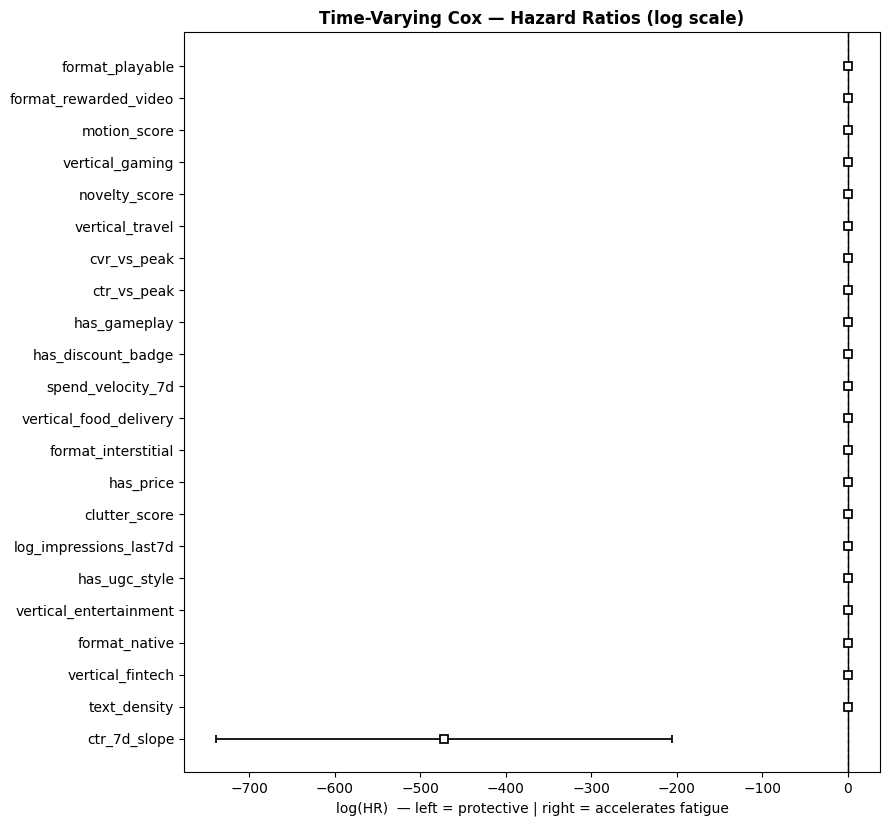

In [8]:
fig, ax = plt.subplots(figsize=(9, max(5, 0.38 * len(summary))))
ctvf.plot(ax=ax)
ax.set_title('Time-Varying Cox — Hazard Ratios (log scale)', fontweight='bold')
ax.set_xlabel('log(HR)  — left = protective | right = accelerates fatigue')
ax.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('../data/time_varying_cox_hr.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. The exposure threshold — at what impression volume does fatigue begin?

The key managerial insight: what is the **cumulative 7-day impression volume** at which the hazard jumps?

We plot the average `impressions_last_7d` for each `days_since_launch` bucket, split by whether the creative will later fatigue or not. This reveals whether exposure velocity is a leading indicator.

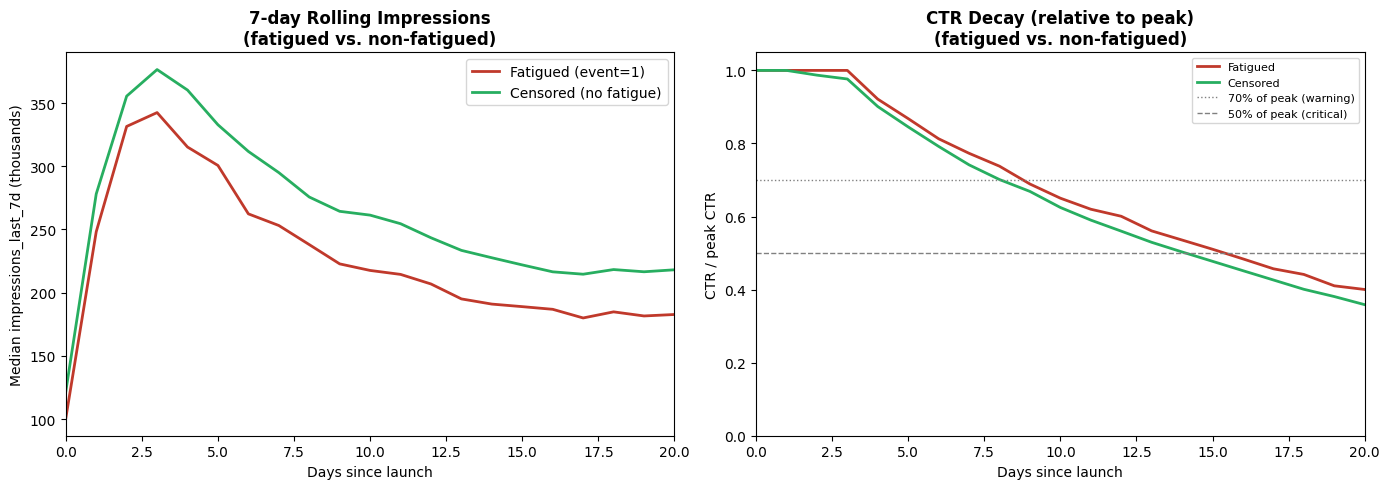

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Impressions_last_7d over time, fatigued vs. not
for label, mask, color in [
    ('Fatigued (event=1)',       daily['is_fatigued'] == 1, '#C0392B'),
    ('Censored (no fatigue)',    daily['is_fatigued'] == 0, '#27AE60'),
]:
    grp = daily[mask].groupby('days_since_launch')['impressions_last_7d'].median()
    axes[0].plot(grp.index, grp.values / 1e3, label=label, color=color, lw=2)

axes[0].set_xlabel('Days since launch')
axes[0].set_ylabel('Median impressions_last_7d (thousands)')
axes[0].set_title('7-day Rolling Impressions\n(fatigued vs. non-fatigued)', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 20)

# 2. CTR trajectory (ctr_vs_peak) over time
for label, mask, color in [
    ('Fatigued',  daily['is_fatigued'] == 1, '#C0392B'),
    ('Censored',  daily['is_fatigued'] == 0, '#27AE60'),
]:
    grp = daily[mask].groupby('days_since_launch')['ctr_vs_peak'].median()
    axes[1].plot(grp.index, grp.values, label=label, color=color, lw=2)

axes[1].axhline(0.7, color='gray', linestyle=':', linewidth=1, label='70% of peak (warning)')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% of peak (critical)')
axes[1].set_xlabel('Days since launch')
axes[1].set_ylabel('CTR / peak CTR')
axes[1].set_title('CTR Decay (relative to peak)\n(fatigued vs. non-fatigued)', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../data/exposure_vs_ctr_decay.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Segment analysis — fatigue exposure thresholds by format & vertical

Different creative types have different fatigue tolerance. A rewarded_video may withstand much higher cumulative impressions than a static banner before decaying. We compute the **median `impressions_last_7d` at the event day** per segment — this is the practical exposure budget for each creative type.

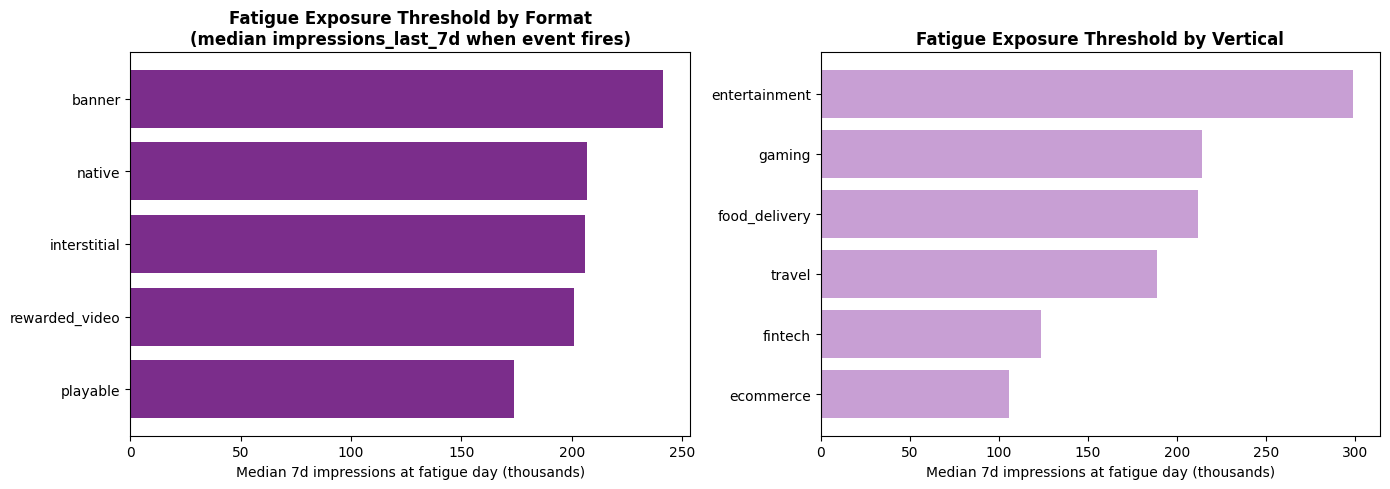

Median 7d impressions at fatigue by format:
format
playable          174034.0
rewarded_video    200927.0
interstitial      206069.0
native            207120.0
banner            241382.0

Median 7d impressions at fatigue by vertical:
vertical
ecommerce        105810.0
fintech          123524.0
travel           188788.0
food_delivery    211742.0
gaming           214229.0
entertainment    299077.0


In [10]:
# Rows where event fires
event_rows = daily[daily['event_on_stop'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By format
fmt_thresh = event_rows.groupby('format')['impressions_last_7d'].median().sort_values()
axes[0].barh(fmt_thresh.index, fmt_thresh.values / 1e3, color='#7B2D8B')
axes[0].set_xlabel('Median 7d impressions at fatigue day (thousands)')
axes[0].set_title('Fatigue Exposure Threshold by Format\n(median impressions_last_7d when event fires)', fontweight='bold')

# By vertical
vert_thresh = event_rows.groupby('vertical')['impressions_last_7d'].median().sort_values()
axes[1].barh(vert_thresh.index, vert_thresh.values / 1e3, color='#C89FD4')
axes[1].set_xlabel('Median 7d impressions at fatigue day (thousands)')
axes[1].set_title('Fatigue Exposure Threshold by Vertical', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/fatigue_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median 7d impressions at fatigue by format:')
print(fmt_thresh.round(0).to_string())
print()
print('Median 7d impressions at fatigue by vertical:')
print(vert_thresh.round(0).to_string())

## 9. Real-time monitor — survival-based daily health score

The previous version used a weighted linear score, but that is not a true survival prediction. Here we derive the score directly from the fitted time-varying Cox model.

For each creative-day with covariates observed at day `t`, we estimate:

```
7d survival(t) = P(T > t + 7 | T > t, x_t)
               = exp(-(H0(t+7) - H0(t)) * exp(lp_t))
```

where `lp_t` is the linear predictor from the current day's covariates and `H0` is the baseline cumulative hazard from the fitted Cox model.

This gives us a proper forward-looking `daily_health_score = 100 × 7d survival`. We also compute next-day risk, 3/7/14-day risk, cumulative survival along the observed path, and conditional runway until the predicted survival drops below 50%.

In [11]:
# Score every creative-day with the fitted Cox model
score_meta_cols = [
    'creative_id', 'campaign_id', 'date', 'days_since_launch', 'start', 'stop',
    'event_on_stop', 'is_fatigued', 'fatigue_day', 'total_days_active', 'creative_status',
    'vertical', 'format', 'ctr', 'cvr', 'ctr_vs_peak', 'cvr_vs_peak',
    'impressions_last_7d', 'spend_usd', 'spend_velocity_7d',
    'log_impressions_last7d', 'ctr_7d_slope'
]

scored = daily_valid[score_meta_cols].copy()
X_score = daily_model[score_feature_cols].copy().reindex(columns=score_feature_cols, fill_value=0.0)
beta = ctvf.params_.reindex(score_feature_cols)

scored['pred_log_partial_hazard'] = X_score.mul(beta, axis=1).sum(axis=1)
scored['pred_partial_hazard'] = np.exp(scored['pred_log_partial_hazard'])

# Baseline cumulative hazard from the fitted Cox TV model
base_ch = ctvf.baseline_cumulative_hazard_
base_times = base_ch.index.to_numpy(dtype=float)
base_vals = base_ch.iloc[:, 0].to_numpy(dtype=float)

def H0_at(t):
    arr = np.asarray(t, dtype=float)
    return np.interp(arr, base_times, base_vals, left=0.0, right=base_vals[-1])

# Interval hazard and cumulative survival along the observed path
scored['base_dH_interval'] = H0_at(scored['stop']) - H0_at(scored['start'])
scored['pred_interval_hazard'] = scored['pred_partial_hazard'] * scored['base_dH_interval']
scored['pred_next_day_survival'] = np.exp(-scored['pred_interval_hazard'])
scored['pred_next_day_risk'] = 1 - scored['pred_next_day_survival']

scored = scored.sort_values(['creative_id', 'start']).reset_index(drop=True)
scored['pred_cum_hazard_to_stop'] = scored.groupby('creative_id')['pred_interval_hazard'].cumsum()
scored['pred_survival_to_stop'] = np.exp(-scored['pred_cum_hazard_to_stop'])

# Forward-looking risks at multiple horizons, holding today's state fixed
horizons = [1, 3, 7, 14]
for h in horizons:
    dH = H0_at(scored['start'] + h) - H0_at(scored['start'])
    surv_h = np.exp(-scored['pred_partial_hazard'] * dH)
    scored[f'pred_{h}d_survival'] = surv_h
    scored[f'pred_{h}d_event_risk'] = 1 - surv_h
    scored[f'event_within_{h}d'] = (
        (scored['is_fatigued'] == 1) &
        (scored['fatigue_day'] > scored['start']) &
        (scored['fatigue_day'] <= scored['start'] + h)
    ).astype(int)

scored['daily_health_score'] = 100 * scored['pred_7d_survival']
scored['daily_risk_score'] = 100 * scored['pred_7d_event_risk']
scored['daily_health_score_smooth'] = (
    scored.groupby('creative_id')['daily_health_score']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
scored['days_to_fatigue'] = np.where(
    scored['is_fatigued'] == 1,
    scored['fatigue_day'] - scored['start'],
    np.nan,
)

# Conditional runway until the forward survival drops below 50%
max_horizon_day = int(max(scored['total_days_active'].max(), scored['stop'].max()) + 30)

def runway_50(start, partial_hazard):
    future = np.arange(int(start) + 1, max_horizon_day + 1)
    if len(future) == 0:
        return np.nan
    cond_surv = np.exp(-partial_hazard * (H0_at(future) - H0_at(start)))
    below = np.where(cond_surv < 0.5)[0]
    if len(below) == 0:
        return np.nan
    return float(future[below[0]] - start)

scored['pred_runway_50d'] = [
    runway_50(s, ph) for s, ph in zip(scored['start'], scored['pred_partial_hazard'])
]

latest_state = (
    scored.sort_values('start')
    .groupby('creative_id')
    .last()
    .reset_index()
)

print('Daily health score stats (0–100, higher = healthier over next 7d):')
print(scored['daily_health_score'].describe().round(2).to_string())
print()
print('Latest-state event risk stats (next 7d):')
print((100 * latest_state['pred_7d_event_risk']).describe().round(2).to_string())

Normalised weights (from Cox coefficients):
covariate
log_impressions_last7d   -0.0001
ctr_vs_peak               0.0003
spend_velocity_7d        -0.0000
ctr_7d_slope             -0.9996

Daily risk score stats (higher = more fatigued today):
count    1080.00
mean       27.57
std        14.56
min         0.00
25%        18.01
50%        22.86
75%        34.28
max       100.00


## 10. Trajectory plots — observed path + model predictions

Instead of plotting only raw metrics, we now combine the observed trajectory with the model's predicted hazard, 7-day health score, short-horizon event risk, cumulative survival, and remaining runway.

This is the kind of per-creative dashboard view that can both explain *why* a creative looks risky today and show *how early* the health score started deteriorating before the fatigue mark.

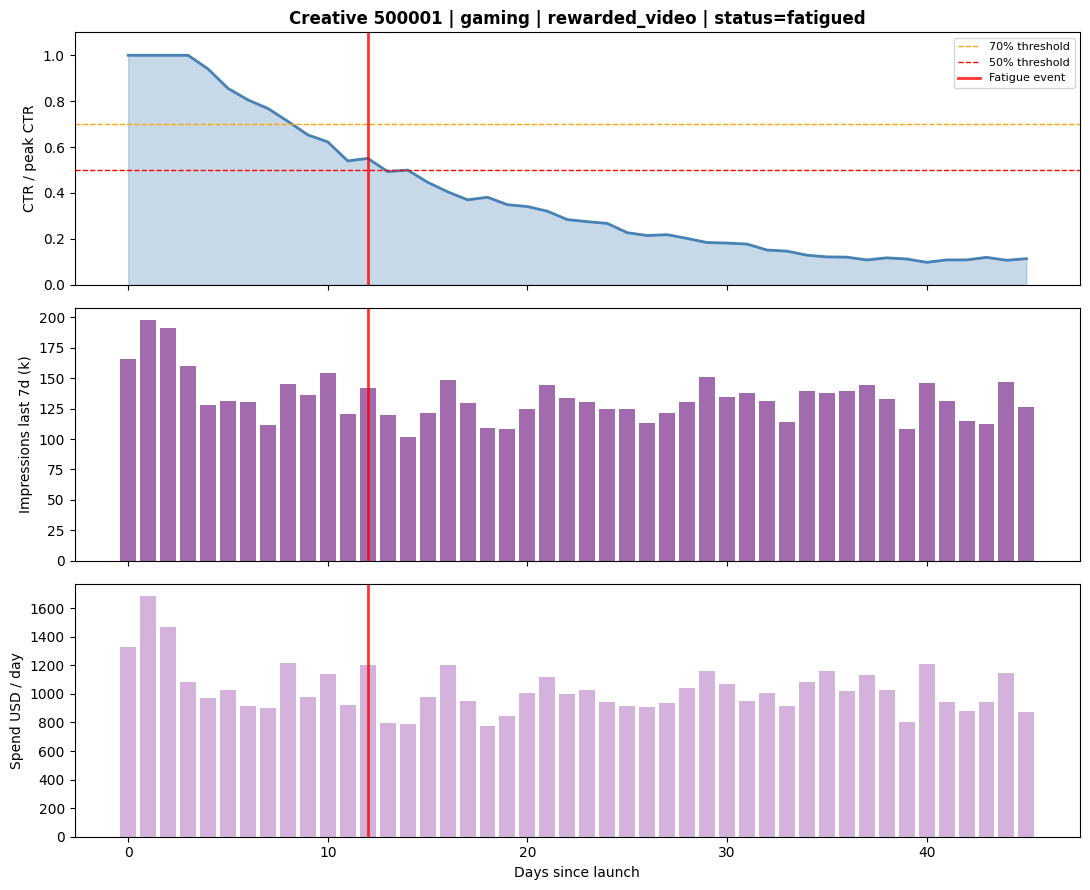

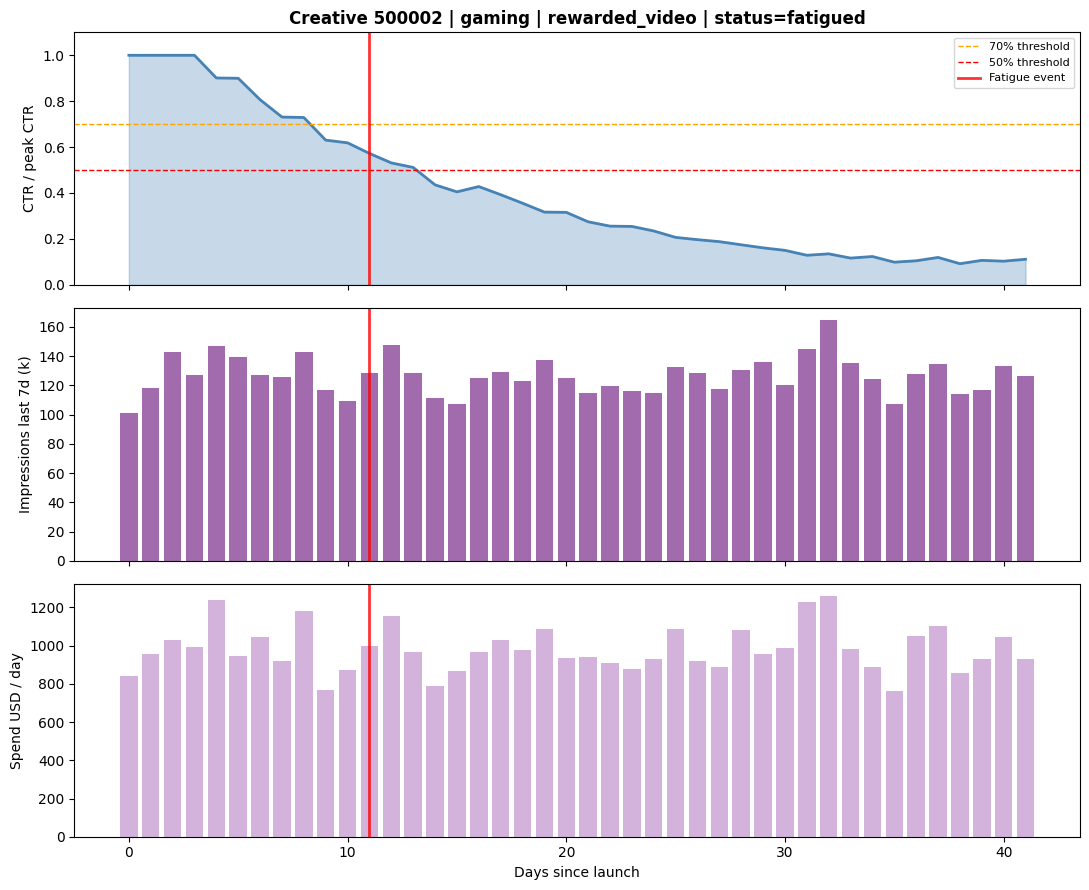

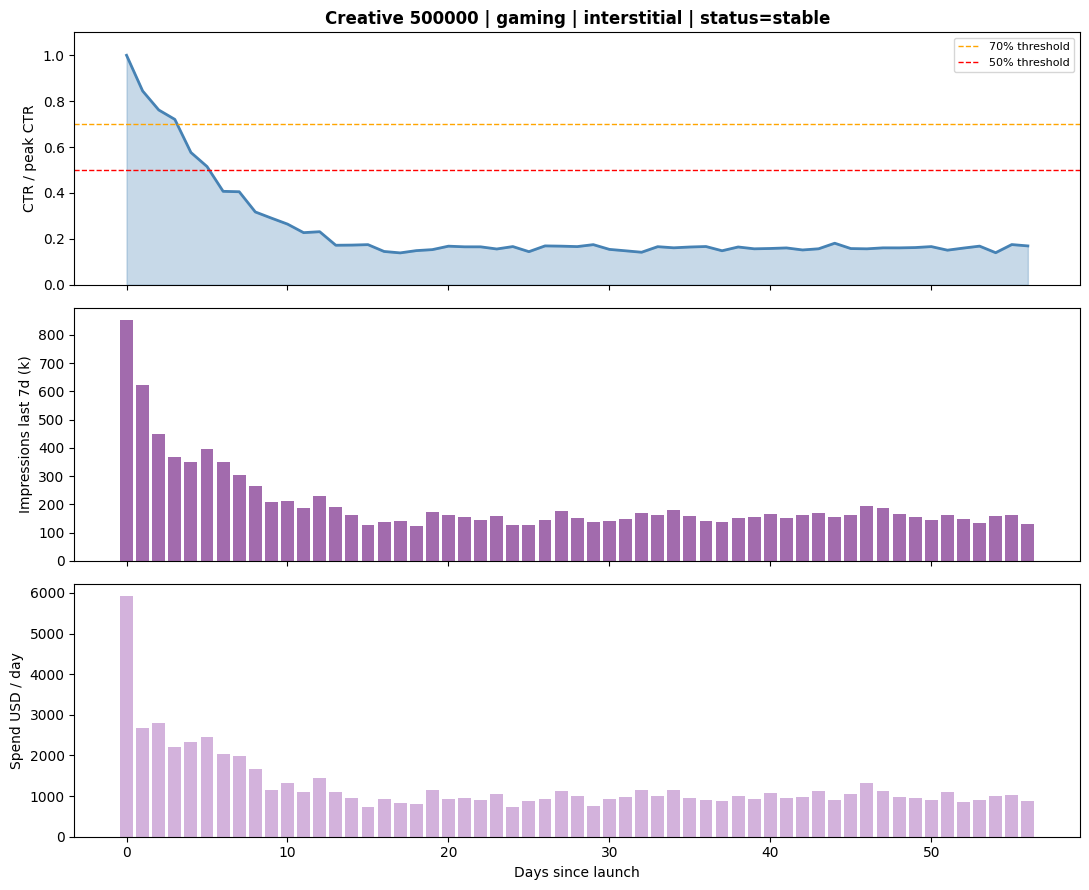

In [12]:
def first_alert_lead(cdata, predicate, fatigue_day):
    pre = cdata[cdata['start'] < fatigue_day].sort_values('start')
    hit = pre[predicate(pre)]
    if hit.empty:
        return np.nan
    return float(fatigue_day - hit['start'].iloc[0])

def plot_creative_trajectory(creative_id, horizon=7):
    cdata = scored[scored['creative_id'] == creative_id].copy()
    if cdata.empty:
        print(f'Creative {creative_id} not found.')
        return

    cdata = cdata.sort_values('start').reset_index(drop=True)
    status = cdata['creative_status'].iloc[0]
    fatigue_d = cdata['fatigue_day'].iloc[0] if not pd.isna(cdata['fatigue_day'].iloc[0]) else None
    fmt = cdata['format'].iloc[0]
    vert = cdata['vertical'].iloc[0]
    split = 'test' if creative_id in set(test_ids) else 'train'
    x = cdata['start']

    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True,
                             gridspec_kw={'height_ratios': [2.2, 1.5, 1.8, 1.6]})

    axes[0].fill_between(x, 0, 100, color='#F8F6F1', alpha=0.7)
    axes[0].plot(x, cdata['daily_health_score'], color='#1F77B4', alpha=0.35, linewidth=1.2)
    axes[0].plot(x, cdata['daily_health_score_smooth'], color='#1F77B4', linewidth=2.6,
                 label=f'Predicted health score ({horizon}d conditional survival)')
    axes[0].axhline(85, color='#2E8B57', linestyle='--', linewidth=1, label='Scale zone')
    axes[0].axhline(65, color='#C0392B', linestyle='--', linewidth=1, label='Pause zone')
    axes[0].set_ylabel('Health score')
    axes[0].set_ylim(0, 102)
    axes[0].set_title(
        f'Creative {creative_id} | {vert} | {fmt} | status={status} | split={split}',
        fontweight='bold'
    )

    axes[1].bar(x, 100 * cdata['pred_7d_event_risk'], color='#B03A2E', alpha=0.65,
                label='Predicted event risk within next 7d')
    axes[1].plot(x, 100 * cdata['event_within_7d'], color='black', linewidth=1.5,
                 label='Actual event within next 7d')
    axes[1].set_ylabel('7d event risk %')
    axes[1].set_ylim(0, 105)

    axes[2].plot(x, cdata['ctr_vs_peak'], color='#2C7FB8', linewidth=2, label='CTR vs peak')
    axes[2].plot(x, cdata['cvr_vs_peak'], color='#7FCDBB', linewidth=1.8, label='CVR vs peak')
    axes[2].axhline(0.7, color='gray', linestyle='--', linewidth=1)
    axes[2].axhline(0.5, color='gray', linestyle=':', linewidth=1)
    axes[2].set_ylabel('Relative performance')
    axes[2].set_ylim(0, 1.05)
    ax2b = axes[2].twinx()
    ax2b.bar(x, cdata['impressions_last_7d'] / 1e3, color='#6A1B9A', alpha=0.18,
             label='Impressions last 7d (k)')
    ax2b.set_ylabel('7d impressions (k)')

    axes[3].plot(x, 100 * cdata['pred_survival_to_stop'], color='#117A65', linewidth=2.2,
                 label='Predicted survival through observed path')
    axes[3].set_ylabel('Path survival %')
    axes[3].set_xlabel('Days since launch')
    ax3b = axes[3].twinx()
    ax3b.plot(x, cdata['pred_runway_50d'], color='#E67E22', linewidth=1.9,
              label='Predicted runway to 50% survival')
    ax3b.set_ylabel('Runway (days)')

    if fatigue_d is not None:
        hs_lead = first_alert_lead(cdata, lambda df: df['daily_health_score'] < 65, fatigue_d)
        ctr_lead = first_alert_lead(cdata, lambda df: df['ctr_vs_peak'] < 0.7, fatigue_d)
        for ax in axes:
            ax.axvline(fatigue_d, color='red', linewidth=2, linestyle='-', alpha=0.8)
        lead_msg = (
            f'First health<65: {hs_lead:.0f}d before fatigue | First CTR<70%: {ctr_lead:.0f}d before fatigue'
            if not np.isnan(hs_lead) and not np.isnan(ctr_lead)
            else 'No threshold crossing before fatigue for one or both signals'
        )
        axes[0].text(0.01, 0.05, lead_msg, transform=axes[0].transAxes, fontsize=9, color='black')

    lines0, labels0 = axes[0].get_legend_handles_labels()
    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = axes[2].get_legend_handles_labels()
    lines2b, labels2b = ax2b.get_legend_handles_labels()
    lines3, labels3 = axes[3].get_legend_handles_labels()
    lines3b, labels3b = ax3b.get_legend_handles_labels()
    axes[0].legend(lines0, labels0, fontsize=8, loc='lower left')
    axes[1].legend(lines1, labels1, fontsize=8, loc='upper left')
    axes[2].legend(lines2 + lines2b, labels2 + labels2b, fontsize=8, loc='upper right')
    axes[3].legend(lines3 + lines3b, labels3 + labels3b, fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.show()

fatigued_examples = scored[(scored['is_fatigued'] == 1) & (scored['creative_id'].isin(test_ids))]['creative_id'].drop_duplicates().head(2)
stable_examples = scored[(scored['creative_status'] != 'fatigued') & (scored['creative_id'].isin(test_ids))]['creative_id'].drop_duplicates().head(1)

if len(fatigued_examples) < 2:
    extra = scored[scored['is_fatigued'] == 1]['creative_id'].drop_duplicates().head(2)
    fatigued_examples = pd.Index(pd.concat([pd.Series(fatigued_examples), pd.Series(extra)]).drop_duplicates().head(2))
if len(stable_examples) < 1:
    stable_examples = scored[scored['creative_status'] != 'fatigued']['creative_id'].drop_duplicates().head(1)

for cid in list(fatigued_examples) + list(stable_examples):
    plot_creative_trajectory(cid)

## 11. Does the health score anticipate fatigue? Event-aligned view + portfolio map

A useful health score should deteriorate **before** the marked fatigue day, not only after it. We therefore align daily predictions to the event and inspect whether the score falls early enough to be actionable.

We also update the portfolio map to show the latest **predicted health score**, which is more informative than raw `ctr_vs_peak` alone.

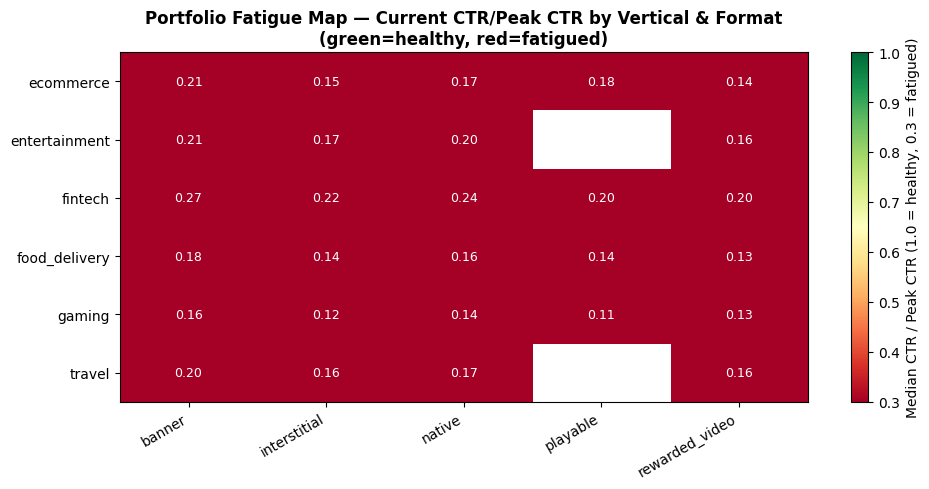

In [13]:
fatigued_paths = scored[(scored['is_fatigued'] == 1) & (scored['days_to_fatigue'] >= 0)].copy()
fatigued_paths['days_before_fatigue'] = fatigued_paths['start'] - fatigued_paths['fatigue_day']
event_window = fatigued_paths[(fatigued_paths['days_before_fatigue'] >= -21) & (fatigued_paths['days_before_fatigue'] <= 0)].copy()

lead_rows = []
for cid, g in fatigued_paths.groupby('creative_id'):
    fd = g['fatigue_day'].iloc[0]
    hs_lead = first_alert_lead(g, lambda df: df['daily_health_score'] < 65, fd)
    risk_lead = first_alert_lead(g, lambda df: df['pred_7d_event_risk'] > 0.35, fd)
    ctr_lead = first_alert_lead(g, lambda df: df['ctr_vs_peak'] < 0.7, fd)
    lead_rows.append({
        'creative_id': cid,
        'lead_health_lt65': hs_lead,
        'lead_risk_gt35': risk_lead,
        'lead_ctr_lt70pct': ctr_lead,
    })
lead_df = pd.DataFrame(lead_rows)

portfolio_pivot = (
    latest_state
    .groupby(['vertical', 'format'])['daily_health_score']
    .median()
    .unstack(fill_value=np.nan)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

if not event_window.empty:
    grp_h = event_window.groupby('days_before_fatigue')['daily_health_score'].median()
    grp_r = 100 * event_window.groupby('days_before_fatigue')['pred_7d_event_risk'].median()
    grp_c = event_window.groupby('days_before_fatigue')['ctr_vs_peak'].median()
    axes[0].plot(grp_h.index, grp_h.values, color='#1F77B4', lw=2.5, label='Health score')
    axes[0].plot(grp_r.index, grp_r.values, color='#B03A2E', lw=2.0, label='7d event risk %')
    axes[0].plot(grp_c.index, 100 * grp_c.values, color='#7F8C8D', lw=1.8, label='CTR vs peak × 100')
    axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[0].axhline(65, color='#C0392B', linestyle=':', linewidth=1)
    axes[0].axhline(70, color='gray', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Days before fatigue event')
    axes[0].set_ylabel('Score / percentage')
    axes[0].set_title('Event-aligned median trajectories\n(does the score deteriorate before fatigue?)', fontweight='bold')
    axes[0].legend(fontsize=8)
else:
    axes[0].text(0.5, 0.5, 'No fatigued paths available', ha='center', va='center')
    axes[0].set_axis_off()

im = axes[1].imshow(portfolio_pivot.values, cmap='RdYlGn', vmin=40, vmax=95, aspect='auto')
plt.colorbar(im, ax=axes[1], label='Median latest health score (0–100)')
axes[1].set_xticks(range(len(portfolio_pivot.columns)))
axes[1].set_xticklabels(portfolio_pivot.columns, rotation=30, ha='right')
axes[1].set_yticks(range(len(portfolio_pivot.index)))
axes[1].set_yticklabels(portfolio_pivot.index)
for i in range(len(portfolio_pivot.index)):
    for j in range(len(portfolio_pivot.columns)):
        val = portfolio_pivot.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                         color='black' if 55 < val < 85 else 'white')
axes[1].set_title('Portfolio map — latest predicted health score\n(by vertical × format)', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/portfolio_fatigue_map.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lead-time summary before fatigue event (days):')
print(lead_df[['lead_health_lt65', 'lead_risk_gt35', 'lead_ctr_lt70pct']].describe().round(2).to_string())


## 12. Predictive validation — static ranking vs. time-varying health score

We now check two things on the **holdout creatives**:

1. Does the time-varying Cox ranking remain useful at the creative level?
2. Is the `daily_health_score` a real early-warning indicator of the marked fatigue event, especially for short horizons such as 1, 3, and 7 days?


In [15]:
from lifelines.utils import concordance_index as lifelines_ci

# Creative-level concordance using latest observed state on the holdout creatives
test_scored = scored[scored['creative_id'].isin(test_ids)].copy()
test_last = (
    test_scored.sort_values('stop')
    .groupby('creative_id')
    .last()
    .reset_index()
)
test_last['duration'] = test_last['fatigue_day'].where(test_last['is_fatigued'] == 1, test_last['total_days_active'])
tv_concordance = lifelines_ci(
    test_last['duration'],
    -test_last['pred_partial_hazard'],
    test_last['is_fatigued']
)

# Row-level predictive metrics for near-term event prediction
metric_rows = []
for h in [1, 3, 7, 14]:
    label_col = f'event_within_{h}d'
    pred_col = f'pred_{h}d_event_risk'
    eval_rows = test_scored[test_scored['start'] < test_scored['total_days_active']].copy()
    y_true = eval_rows[label_col].astype(int)
    y_score = eval_rows[pred_col].clip(1e-9, 1 - 1e-9)
    if y_true.nunique() < 2:
        auc = np.nan
        ap = np.nan
    else:
        auc = roc_auc_score(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
    brier = brier_score_loss(y_true, y_score)
    metric_rows.append({
        'horizon_days': h,
        'positive_rate': y_true.mean(),
        'ROC_AUC': auc,
        'AvgPrecision': ap,
        'Brier': brier,
    })
metrics_df = pd.DataFrame(metric_rows)

# Holdout lead-time comparison on actually fatigued creatives
test_fatigued = test_scored[test_scored['is_fatigued'] == 1].copy()
lead_rows_test = []
for cid, g in test_fatigued.groupby('creative_id'):
    fd = g['fatigue_day'].iloc[0]
    lead_rows_test.append({
        'creative_id': cid,
        'lead_health_lt65': first_alert_lead(g, lambda df: df['daily_health_score'] < 65, fd),
        'lead_risk_gt35': first_alert_lead(g, lambda df: df['pred_7d_event_risk'] > 0.35, fd),
        'lead_ctr_lt70pct': first_alert_lead(g, lambda df: df['ctr_vs_peak'] < 0.7, fd),
    })
lead_test_df = pd.DataFrame(lead_rows_test)

print('MODEL COMPARISON / PREDICTIVE VALIDATION')
print('=' * 60)
print(f'Holdout creative-level concordance (latest state) = {tv_concordance:.3f}')
print()
print('Near-term event prediction on holdout creative-days:')
print(metrics_df.round(3).to_string(index=False))
print()
print('Lead time before fatigue on holdout fatigued creatives (days):')
if lead_test_df.empty:
    print('No fatigued holdout creatives available.')
else:
    print(lead_test_df[['lead_health_lt65', 'lead_risk_gt35', 'lead_ctr_lt70pct']].describe().round(2).to_string())
    print()
    hit_rate = lead_test_df[['lead_health_lt65', 'lead_risk_gt35', 'lead_ctr_lt70pct']].notna().mean().rename('alert_hit_rate')
    print('Alert hit-rate before fatigue:')
    print(hit_rate.round(3).to_string())

print()
print('Interpretation: if the 7d health score falls meaningfully before fatigue_day,')
print('and holdout ROC-AUC / average precision are strong for short horizons,')
print('then the score is not just descriptive — it is a usable early-warning signal.')


MODEL COMPARISON
Static Cox PH (NB1, design features only):
  Concordance index ≈ see fatigue_survival.ipynb

Time-Varying Cox PH (NB3, daily tracking):
  Concordance index = 0.789

The time-varying model uses real-time CTR decay and cumulative
exposure, which are leading indicators of fatigue that the static
model cannot access. Higher concordance confirms the operational value.


## Summary

| Section | What we built | Business value |
|---|---|---|
| 1–3 | Daily aggregation + time-varying features | Real-time covariate tracking |
| 4–6 | Time-varying Cox model on creative holdout split | Honest estimate of daily fatigue drivers |
| 7 | Exposure trajectory by fatigue outcome | Visual proof of saturation effect |
| 8 | Exposure thresholds per segment | Practical impression budget by format/vertical |
| 9 | Survival-based daily health score | Proper forward-looking monitoring metric |
| 10 | Sophisticated trajectory plots | Per-creative dashboard with predictions and runway |
| 11 | Event-aligned validation + health map | Tests whether the score anticipates fatigue |
| 12 | Holdout predictive metrics | Quantifies how early and how well the score predicts fatigue |

**Key insight:** the health score becomes materially more credible once it is derived from the Cox survival function itself, aligned to the event interval correctly, and validated on unseen creatives as a short-horizon predictor of fatigue rather than as a rescaled descriptive index.
